In [1]:
recode_alcohol_drinks_typical <- function(alcohol_drinks_typical_status)
{
    fcase(
        alcohol_drinks_typical_status == "Average Daily Drink Count: 1 or 2","Average Daily Drink Count: 1 or 2",
        alcohol_drinks_typical_status == "Average Daily Drink Count: 3 or 4","Average Daily Drink Count: 3 or 4",
        alcohol_drinks_typical_status == "Average Daily Drink Count: 5 or 6","Average Daily Drink Count: 5 or 6",
        alcohol_drinks_typical_status == "Average Daily Drink Count: 7 to 9","Average Daily Drink Count: 7 to 9",
        alcohol_drinks_typical_status == "Average Daily Drink Count: 10 or More","Average Daily Drink Count: 10 or More",
        default = as.character(NA))
}

recode_alcohol_drinks <- function(alcohol_drinks_status)
{
    fcase(alcohol_drinks_status == "Drink Frequency Past Year: 2 to 3 Per Week","Drink Frequency Past Year: 2 to 3 Per Week",
        alcohol_drinks_status == "Drink Frequency Past Year: 2 to 4 Per Month","Drink Frequency Past Year: 2 to 4 Per Month",
        alcohol_drinks_status == "Drink Frequency Past Year: 4 or More Per Week","Drink Frequency Past Year: 4 or More Per Week",
        alcohol_drinks_status == "Drink Frequency Past Year: Monthly Or Less","Drink Frequency Past Year: Monthly Or Less",
        alcohol_drinks_status == "Drink Frequency Past Year: Never","Drink Frequency Past Year: Never",
       default = as.character(NA))
}


alcohol_drinks_audit_score <- function(x)
{
       as.factor(fcase(x == 'Drink Frequency Past Year: Never', 0,
       x == "Drink Frequency Past Year: Monthly Or Less", 1,
       x == "Drink Frequency Past Year: 2 to 4 Per Month", 2,
       x == "Drink Frequency Past Year: 2 to 3 Per Week", 3,
       x == "Drink Frequency Past Year: 4 or More Per Week", 4,
       default = as.numeric(NA)))
}

recode_smoking <- function(smoking_status)
{
    as.factor(fcase(
#         smoking_status == "PMI: Dont Know", as.character(NA),
#         smoking_status == "PMI: Skip", as.character(NA),
#         smoking_status == "PMI: Prefer Not To Answer", as.character(NA),
        smoking_status == "100 Cigs Lifetime: No","No",
        smoking_status == "100 Cigs Lifetime: Yes","Yes",
        default = as.character(NA)
                                       ))
}



format_tu_data <- function(merged_long_month, event_date_column, 
                           blanking_period_days = 180, 
                           max_years_to_event_from_last = 2)
{
    merged_long_month <- merged_long_month[date < last_medical_encounter_entry_date]
    merged_long_month[!is.na(get(event_date_column)), event_or_censor_date := get(event_date_column)]
    merged_long_month[is.na(get(event_date_column)), event_or_censor_date := last_medical_encounter_entry_date]
    cat("Exclude data after censor date")
    cat("\nN:", length(unique(merged_long_month$person_id)))
    cat("\nMonths", nrow(merged_long_month))
    cat("\nEvents:",nrow(merged_long_month[!is.na(get(event_date_column)),.(n = .N),.(person_id)]))
    merged_long_month <- merged_long_month[order(date)]
    merged_long_month[, (event_date_column) := as.Date(get(event_date_column))]
    merged_long_month[, date_next := as.Date(shift(date,-1)), .(person_id)]
    merged_long_month[, time1 := as.numeric(as.Date(date) - as.Date(min(date))) / 365.25, .(person_id)]
    merged_long_month_sub <- merged_long_month[date < as.Date(get(event_date_column)) | 
                                               is.na(get(event_date_column))]
    merged_long_month_sub[, last_date := date == max(date), .(person_id)]
    merged_long_month_sub[last_date == TRUE, date_next := event_or_censor_date]
    merged_long_month_sub[, status := FALSE]
    merged_long_month_sub[last_date == TRUE & !is.na(get(event_date_column)), status := TRUE]
    merged_long_month_sub[, time2 := as.numeric(as.Date(date_next) - as.Date(min(date))) / 365.25, .(person_id)]
    merged_long_month_sub[, is_valid := get(event_date_column) >= (min(date) + blanking_period_days) |
                          is.na(get(event_date_column)), .(person_id)]
    merged_long_month_sub <- merged_long_month_sub[is_valid == TRUE]
    cat("\n\nExclude events < 180 days after first monitoring date")
    cat("\nN:", length(unique(merged_long_month_sub$person_id)))
    cat("\nMonths", nrow(merged_long_month_sub))
    cat("\nEvents:",nrow(merged_long_month_sub[!is.na(get(event_date_column)),.(n = .N),.(person_id)]))
    merged_long_month_sub[status == TRUE, 
                          time_to_event_from_last_date := as.numeric(as.Date(max(date_next)) 
                                                                     - as.Date(max(date))) / 365.25, 
                          .(person_id)]
    merged_long_month_sub[, 
                          time_to_event_from_last_date_valid := !any(time_to_event_from_last_date > 2,na.rm = T), 
                          .(person_id)]
    merged_long_month_sub <- merged_long_month_sub[time_to_event_from_last_date_valid == TRUE]
    cat("\n\nExclude events > 2 years after last monitoring date")
    cat("\nN:", length(unique(merged_long_month_sub$person_id)))
    cat("\nMonths", nrow(merged_long_month_sub))
    cat("\nEvents:",nrow(merged_long_month_sub[!is.na(get(event_date_column)),.(n = .N),.(person_id)]))
    cat("\n\n")
    return(merged_long_month_sub)
}

get_baseline_status <- function(date,anchor_date)
{
    ifelse(is.na(date), FALSE, as.numeric(as.Date(date) - as.Date(anchor_date)) < 180)
}

get_incident_status <- function(date,anchor_date)
{
    ifelse(is.na(date), FALSE, ifelse(as.numeric(as.Date(date) - as.Date(anchor_date)) >= 180,TRUE,NA))
}


impute_long_data <- function(dat_long,covariates)
{
  set.seed(0)
  vars <- colnames(covariates)
  vars <- vars[-which(vars=="person_id")]
  f <- as.formula(paste0("~",paste0(vars,collapse = "+")))
  xtrans <- Hmisc::aregImpute(f,data = covariates, n.impute = 5, pr = TRUE)

  datc_list<- lapply(1:5,function(x) as.data.frame(Hmisc::impute.transcan(xtrans,
                                                                          imputation=x,
                                                                          data=covariates,
                                                                          list.out=TRUE,
                                                                          pr=FALSE,
                                                                          check=FALSE)))
  datc_list <- lapply(datc_list,function(x) data.frame(cbind(person_id = covariates$person_id, x)))

  dat_list <- list()
  #original dataset
  dat_list[[1]] <- merge(dat_long,covariates,by="person_id", allow.cartesian=TRUE)

  dat_list[[1]]$.imp <- 0
  for (j in 2:(length(datc_list)+1))
  {
    #attach covariates
    dat_list[[j]] <- merge(dat_long,datc_list[[j-1]],by="person_id", allow.cartesian=TRUE)
    dat_list[[j]]$.imp <- j-1
  }

  print(xtrans)

  dat_imp_long <- lapply(dat_list,function(x) data.frame(x))
  dat_imp_long <- do.call(rbind,dat_imp_long)
  dat_mids <- as.mids(dat_imp_long)
  return(dat_mids)
}
  
                                                                    
# act_var1 <- "steps"
# act_var2 <- "sedentary_minutes"
# model <- "model_2"
# xlab <- "Steps"

impute_dataset2 <- function(fitbit_dat_month, merged_tb1, dx_var, act_var1, act_var2) {
    set.seed(0)
    
    dx <- merged_tb1[,.SD,.SDcols = c("person_id", 
                                      str_glue("{dx_var}_entry_date"), 
                                      str_glue("{dx_var}_status"))]
    colnames(dx) <- c("person_id", "dx_entry_date", "dx_status")

    fitbit_fmt <- format_tu_data(fitbit_dat_month, paste0(dx_var, "_entry_date"))
    fitbit_fmt <- fitbit_fmt[, c("person_id", str_glue("mean_{act_var1}"), str_glue("mean_{act_var2}"),"mean_wear_time", "time1", "time2", "status")]

    cov <- merged_tb1[person_id %in% unique(fitbit_fmt$person_id), .SD,
                      .SDcols= c(str_glue("mean_{act_var1}"), str_glue("mean_{act_var2}"),
                                 "person_id", "age_at_baseline", "sex_recode", "race_recode",
                                 "alcohol_drinks_audit_score", "bmi", str_glue("incident_{dx_var}"),
                                 "education_recode", "smoking_recode", "closest_bp_systolic")]

    colnames(cov)[1:2] <- c(paste0("imp_", colnames(cov)[1]), paste0("imp_", colnames(cov)[2]))

    dat_imp <- impute_long_data(fitbit_fmt, cov)
}


model_2 <- function(e)
{
    f <- as.formula(str_glue("Surv(time1,time2,status) ~ rcs(mean_{act_var1},3) + rcs(mean_{act_var2},3) +
                                mean_wear_time + 
                                rcs(age_at_baseline,3) + sex_recode + 
                               smoking_recode + alcohol_drinks_audit_score + education_recode",
                             #+ rcs(closest_bp_systolic,3) + rcs(bmi,3)",
                             .envir=e))
}

run_model2 <- function(model,dat_imp,act_var1="steps", act_var2="sedentary_minutes")
{
    d1 <- complete(dat_imp,0)
    dd <<- datadist(d1)
    options(datadist = "dd")
    model <- match.fun(model)
    f <- model(environment())
    out <- Hmisc::fit.mult.impute(f,cph,xtrans=dat_imp,data=d1,pr=FALSE,fitargs = list(surv=T,y=T,x=T))
    IRdisplay::display(out)
    display_rms_summary(out)
    display_rms_anova(out)
    ph <- survival::cox.zph(cph(f,data=complete(dat_imp,1)))
    IRdisplay::display("Test of PH")
    IRdisplay::display(ph)
    return(out)
}
             
                         
                         
set_plot_dim <- function(res,height,width) {
    options(repr.plot.res = res, repr.plot.height = height, repr.plot.width = width)  
}                     

In [2]:
if (!require(aou.bucket))
{
    devtools::install_github("annisjs/aou.bucket", upgrade = F)
    require(aou.bucket)
}
sync_packages()

Loading required package: aou.bucket



character(0)

In [3]:
## Loading libraries
library(aou.phenotyper2)
library(aou.display)
library(aou.misc)
library(aou.bucket)

library(stringr)
library(data.table)
library(lubridate)
library(Hmisc)
library(ggplot2)
library(Rmisc)
library(survival)
library(mice)
library(ggpubr)
library(ggplot2)
library(viridis)

library(rms)
library(nlme)
library(dplyr)
library(table1)
library(zoo)


Attaching package: ‘aou.misc’


The following object is masked _by_ ‘.GlobalEnv’:

    recode_smoking



Attaching package: ‘lubridate’


The following objects are masked from ‘package:data.table’:

    hour, isoweek, isoyear, mday, minute, month, quarter, second, wday,
    week, yday, year


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union



Attaching package: ‘Hmisc’


The following objects are masked from ‘package:base’:

    format.pval, units


Loading required package: lattice

Loading required package: plyr


Attaching package: ‘plyr’


The following objects are masked from ‘package:Hmisc’:

    is.discrete, summarize



Attaching package: ‘mice’


The following object is masked from ‘package:stats’:

    filter


The following objects are masked from ‘package:base’:

    cbind, rbind



Attaching package: ‘ggpubr’


The following object is masked from ‘package:plyr’:

    mutate


Loading required package: viridisLite


Attaching pack

In [4]:
# Setting up data pull
output_folder <- "datasets"
pull_data <- FALSE
pull_closest_data <- FALSE

In [5]:
# Data pull
if (pull_data)
{
    afib(output_folder)
    heart_failure(output_folder)
    hyperlipidemia(output_folder)
    alcohol(output_folder) 
    alcohol_drinks(output_folder) 
    demographics(output_folder) 
    diabetes(output_folder) 
    first_medical_encounter(output_folder) 
    gerd(output_folder) 
    hypertension(output_folder) 
    last_medical_encounter(output_folder) 
    major_depressive_disorder(output_folder) 
    obesity(output_folder) 
    obesity_bmi(output_folder) 
    sleep_apnea(output_folder) 
    smoking(output_folder) 
    fitbit(output_folder) 
    sleep(output_folder) 
    wear_time(output_folder)
    cad(output_folder)
    cancer(output_folder)
    education(output_folder)
}

# Pulling other demographic data
if (pull_closest_data)
{
    anchor_date_table <- fitbit_dat[,.(anchor_date = min(date)),.(person_id)]
    closest_bmi("datasets",anchor_date_table,-100000,180)
    closest_bp("datasets",anchor_date_table,-100000,180)
}

NULL

In [6]:
# Loading data
wear_time_dat <- read_bucket("datasets/wear_time.csv")
fitbit_dat <- read_bucket("datasets/fitbit.csv")
sleep_dat <- read_bucket("datasets/sleep.csv")
dem <- read_bucket("datasets/demographics.csv")
last_enc <- read_bucket("datasets/last_medical_encounter.csv")

In [7]:
### Cleaning Activity Data
fitbit_dat <- clean_fitbit(fitbit_dat,wear_time_dat,dem[,c("person_id","date_of_birth")])


Initial cohort
N:  58527
Days:  41435880

Removing days where wear time < 10 hrs.
N:  55560
Days:  34194751

Removing days where step count < 100.
N:  55528
Days:  34159143

Removing days where step counts > 45,000.
N:  55527
Days:  34147147

Removing days where age < 18.
N:  55518
Days:  34115121

In [8]:
### Cleaning Sleep Data

# Initial Fitbit sleep cohort
cat("\nInitial Fitbit sleep cohort")
cat("\nN: ", length(unique(sleep_dat$person_id)))
cat("\nDays: ", nrow(sleep_dat))

# Removing non-main sleep
cat("\n\nRemoving is_main_sleep is FALSE")
fitbit_sleep_dat <- sleep_dat[is_main_sleep == TRUE]
cat("\nN:",length(unique(fitbit_sleep_dat$person_id)))
cat("\nDays:",nrow(fitbit_sleep_dat))

# Removing days with 0 minutes asleep
cat("\n\nRemoving days with 0 minutes asleep")
fitbit_sleep_dat <- fitbit_sleep_dat[minute_asleep > 0]
cat("\nN:",length(unique(fitbit_sleep_dat$person_id)))
cat("\nDays:",nrow(fitbit_sleep_dat))

# Removing days with > 1440 minutes asleep
cat("\n\nRemoving days with >= 1440 minutes asleep")
fitbit_sleep_dat <- fitbit_sleep_dat[minute_asleep < 1440]
cat("\nN:",length(unique(fitbit_sleep_dat$person_id)))
cat("\nDays:",nrow(fitbit_sleep_dat))

# Removing subjects with > 30% days with < 4 hours sleep
cat("\n\nRemoving subjects > 30% days < 4 hours sleep")
fitbit_sleep_dat[, proportion_lt_4hr_asleep := mean(minute_asleep < 4*60),.(person_id)]
fitbit_sleep_dat <- fitbit_sleep_dat[proportion_lt_4hr_asleep <= .30]
cat("\nN:",length(unique(fitbit_sleep_dat$person_id)))
cat("\nDays:",nrow(fitbit_sleep_dat))


Initial Fitbit sleep cohort
N:  54322
Days:  31844165

Removing is_main_sleep is FALSE
N: 54313
Days: 27637194

Removing days with 0 minutes asleep
N: 54313
Days: 27634813

Removing days with >= 1440 minutes asleep
N: 54313
Days: 27634741

Removing subjects > 30% days < 4 hours sleep
N: 44434
Days: 25731943

In [9]:
# Merging activity data and sleep data
cat("Merging activity data with sleep data")
fitbit_dat <- merge(fitbit_dat,
              fitbit_sleep_dat[,c('person_id', 'sleep_date', 'minute_asleep')],
              by.x=c('person_id', 'date'), by.y = c('person_id', 'sleep_date'))
cat("\nN:",length(unique(fitbit_dat$person_id)))
cat("\nDays:",nrow(fitbit_dat))       


Merging activity data with sleep data
N: 43870
Days: 23819776

In [10]:
# Excluding patients without EHR
cat("Excluding those without EHR:")
fitbit_dat <- merge(fitbit_dat,last_enc,by="person_id")
fitbit_dat[, last_medical_encounter_entry_date := NULL]
cat("\nN:",length(unique(fitbit_dat$person_id)))
cat("\nDays:",nrow(fitbit_dat))

Excluding those without EHR:
N: 26089
Days: 13759286

In [11]:
### Final clean up of data
cat("Excluding days with sedentary minutes = 0")
fitbit_dat <- fitbit_dat[sedentary_minutes != 0]
cat("\nN:", length(unique(fitbit_dat$person_id)))
cat("\nDays:", nrow(fitbit_dat))


cat("\n\nExcluding days with sedentary minutes >= 1440")
fitbit_dat <- fitbit_dat[sedentary_minutes < 1440]
cat("\nN:", length(unique(fitbit_dat$person_id)))
cat("\nDays:", nrow(fitbit_dat))

cat("\n\nExcluding days with sedentary minutes + sleep minutes >= 1440")
fitbit_dat <- fitbit_dat[sedentary_minutes + minute_asleep < 1400]
cat("\nN:", length(unique(fitbit_dat$person_id)))
cat("\nDays:", nrow(fitbit_dat))


Excluding days with sedentary minutes = 0
N: 26086
Days: 13732100

Excluding days with sedentary minutes >= 1440
N: 26086
Days: 13732052

Excluding days with sedentary minutes + sleep minutes >= 1440
N: 26078
Days: 13682755

[1] -0.5336904

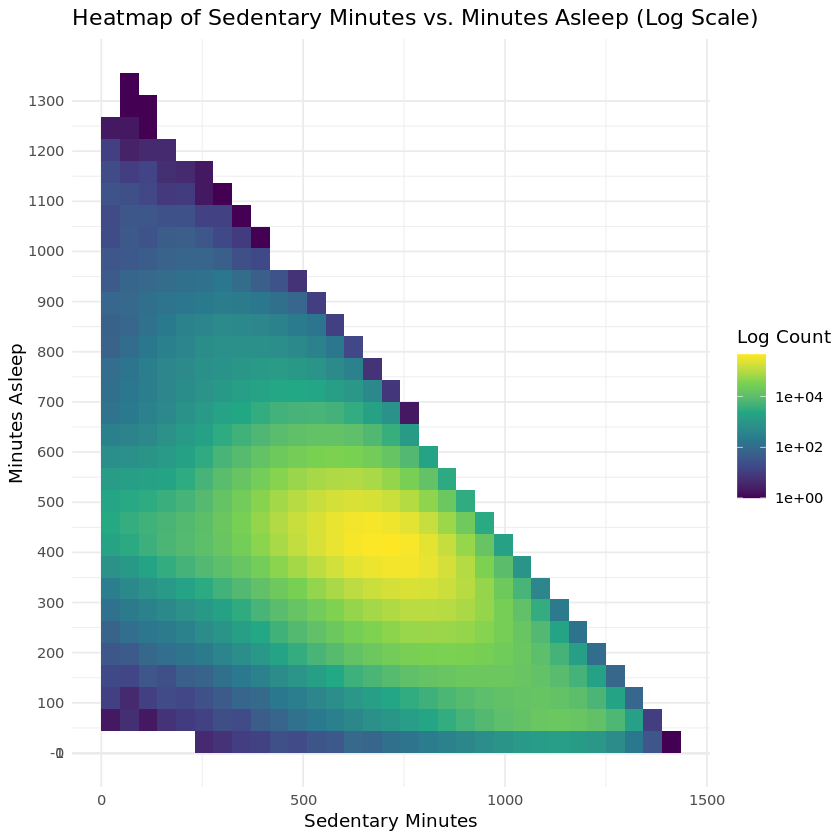

In [12]:
# Plot sedentary time by sleep time
ggplot(fitbit_dat, aes(x = sedentary_minutes, y = minute_asleep)) +
  geom_bin2d(bins = 30) +
  scale_fill_viridis_c(trans = "log10") +
  scale_y_continuous(breaks = c(-1, seq(0, max(fitbit_dat$minute_asleep, na.rm = TRUE), by = 100))) +
  labs(title = "Heatmap of Sedentary Minutes vs. Minutes Asleep (Log Scale)",
       x = "Sedentary Minutes",
       y = "Minutes Asleep",
       fill = "Log Count") +
  theme_minimal()

cor(fitbit_dat$minute_asleep, fitbit_dat$sedentary_minutes)

In [13]:
### Creating aggregated measures
fitbit_agg <- fitbit_dat[,.(mean_steps = mean(steps),
                            mean_sedentary_hours = mean(sedentary_minutes, na.rm = T)/60,
                            mean_lightly_active_minutes = mean(lightly_active_minutes, na.rm = T),
                            mean_fairly_active_minutes = mean(fairly_active_minutes, na.rm = T),
                            mean_very_active_minutes = mean(very_active_minutes, na.rm = T),
                            mean_sleep_hours = mean(minute_asleep, na.rm = T)/60,
                            min_fitbit_date = min(date),
                            max_fitbit_date = max(date),
                            fitbit_duration_years = as.numeric(max(date) - min(date))/365.25),
                         .(person_id)]

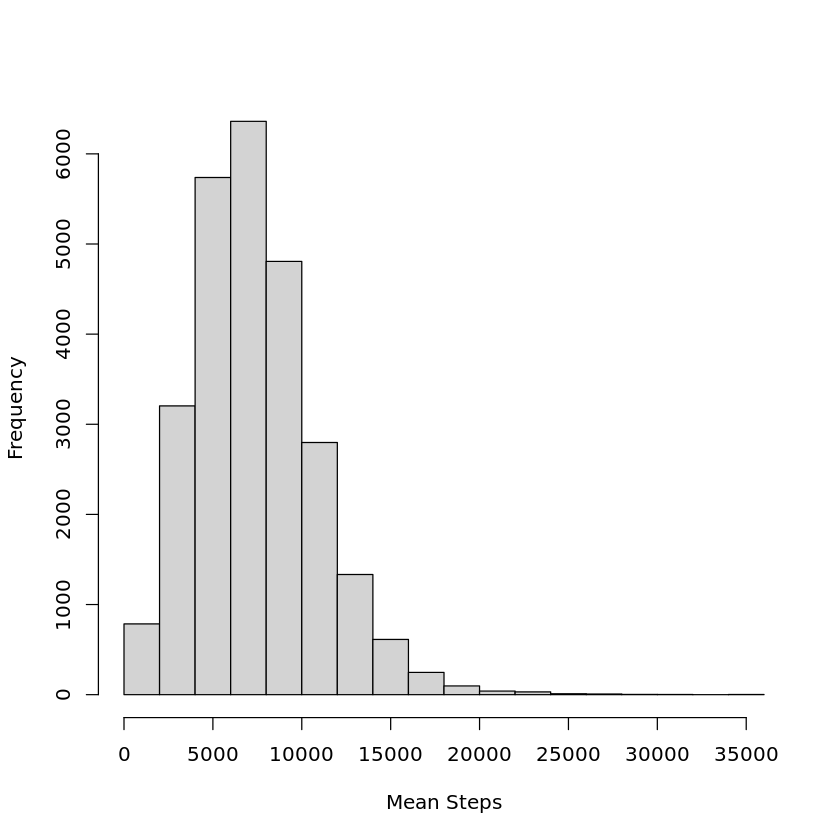

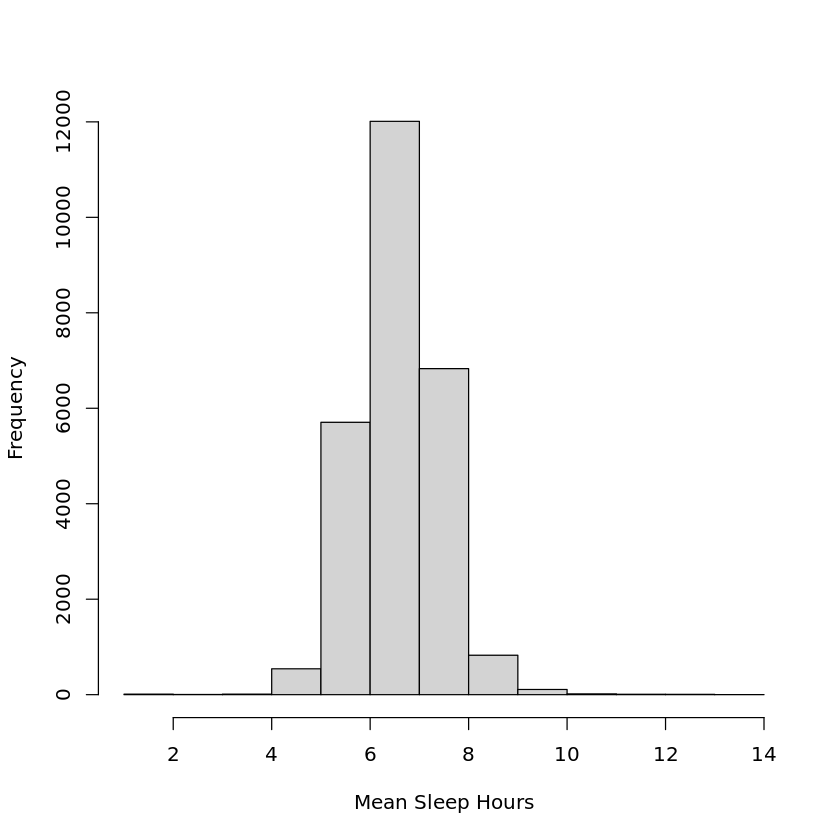

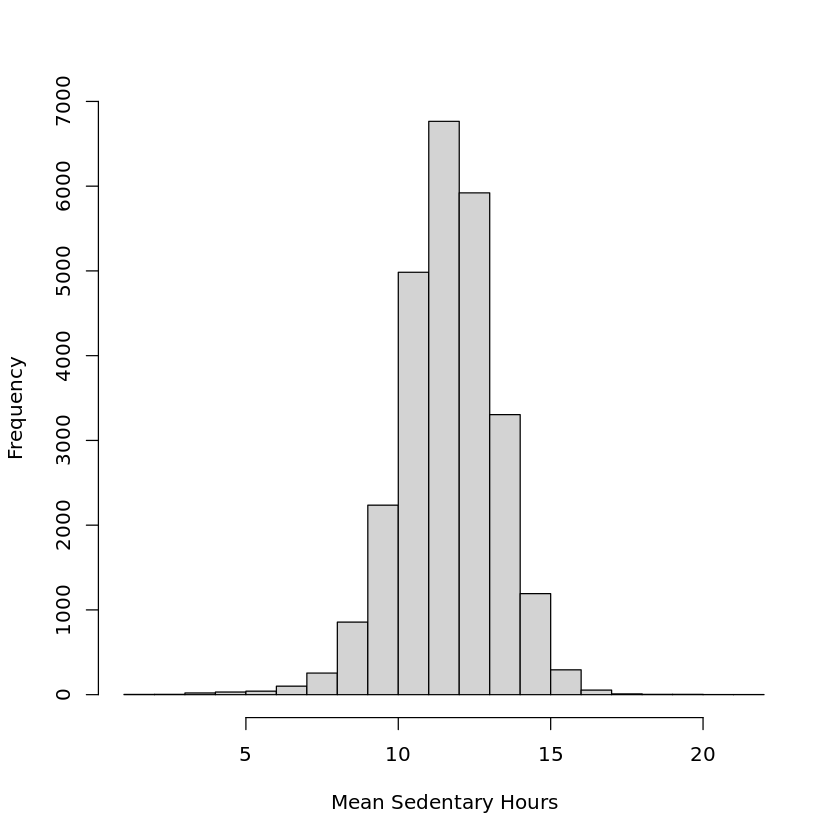

In [14]:
hist(fitbit_agg$mean_steps, 
     main = "", xlab = "Mean Steps")

hist(fitbit_agg$mean_sleep_hours, 
     main = "", xlab = "Mean Sleep Hours")

hist(fitbit_agg$mean_sedentary_hours, 
     main = "", xlab = "Mean Sedentary Hours")



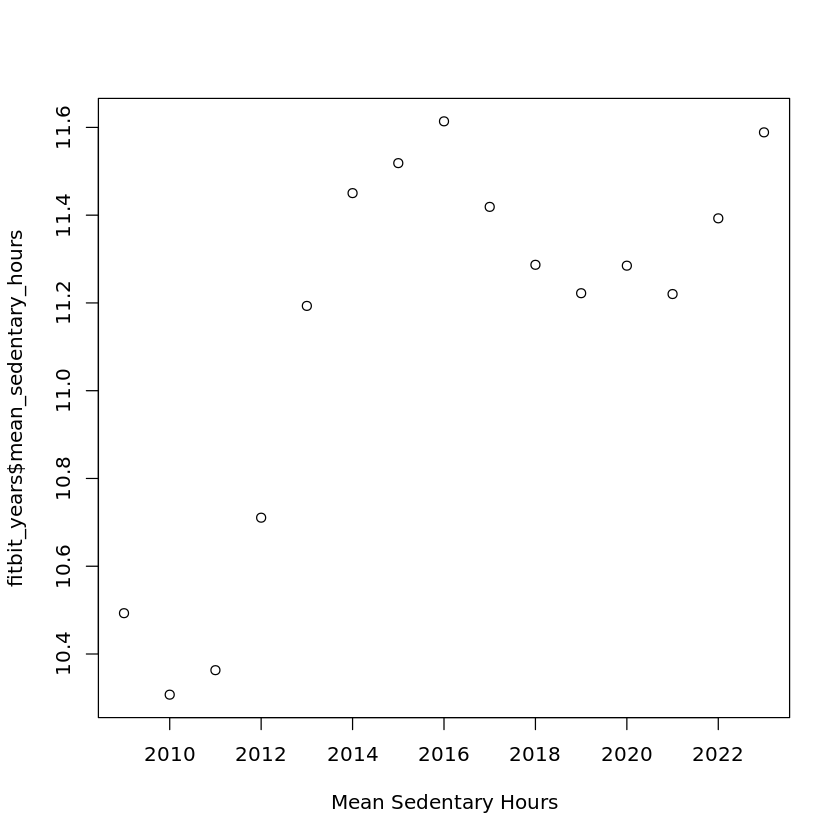

In [15]:
### Sedentary hours over years
fitbit_years <- fitbit_dat[,.(mean_steps = mean(steps),
                            mean_sedentary_hours = mean(sedentary_minutes, na.rm = T)/60,
                            mean_lightly_active_minutes = mean(lightly_active_minutes, na.rm = T),
                            mean_fairly_active_minutes = mean(fairly_active_minutes, na.rm = T),
                            mean_very_active_minutes = mean(very_active_minutes, na.rm = T),
                            mean_sleep_hours = mean(minute_asleep, na.rm = T)/60,
                            min_fitbit_date = min(date),
                            max_fitbit_date = max(date),
                            fitbit_duration_years = as.numeric(max(date) - min(date))/365.25),
                         .(year(date))]
plot( fitbit_years$year, fitbit_years$mean_sedentary_hours,
     main = "", xlab = "Mean Sedentary Hours")

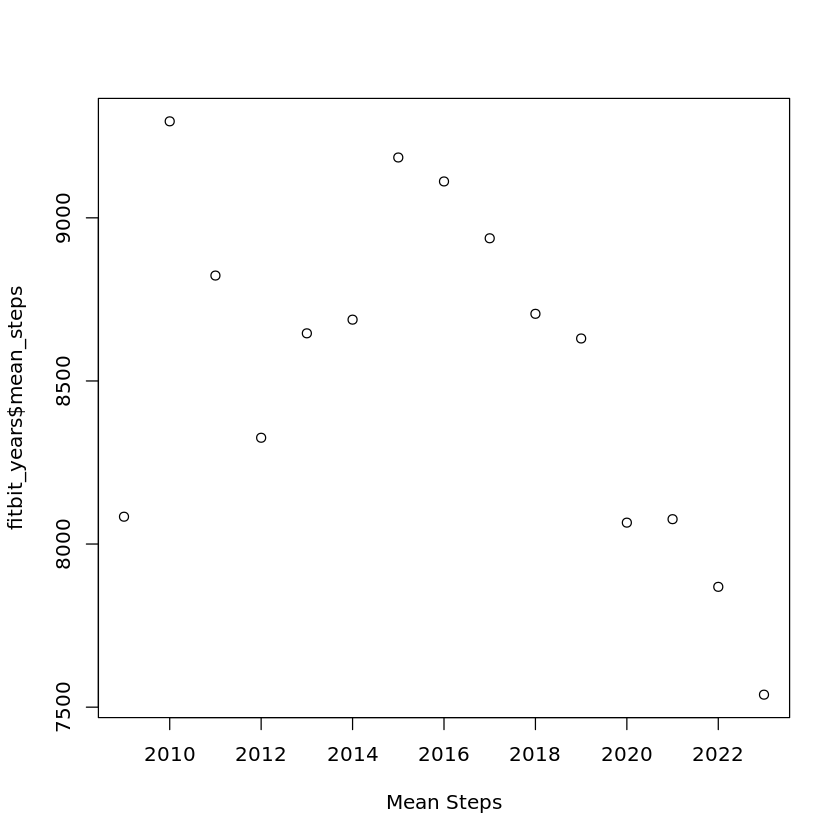

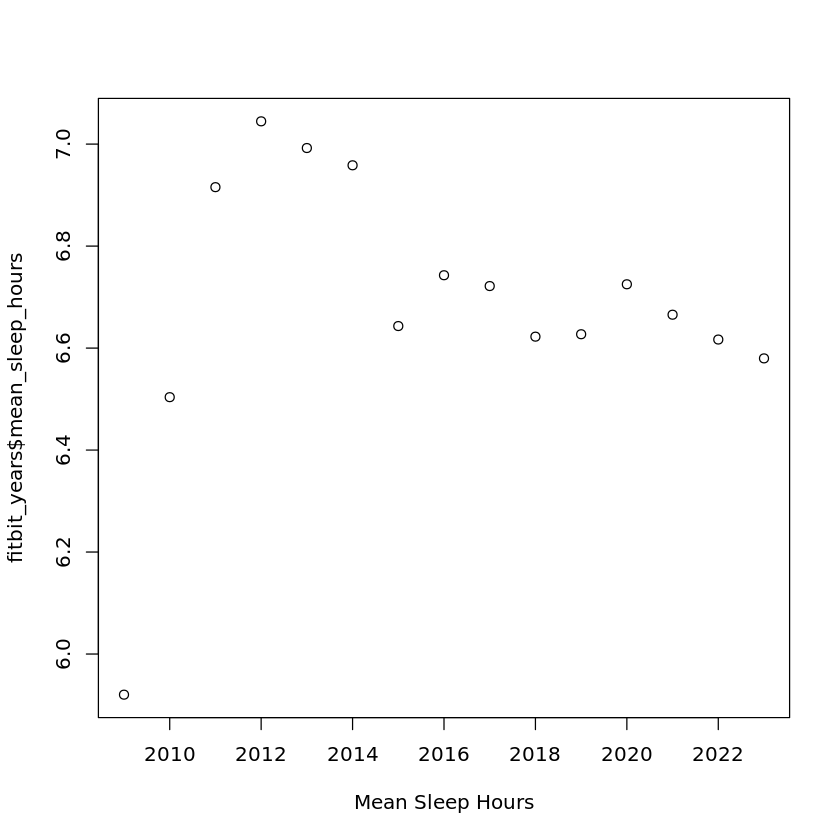

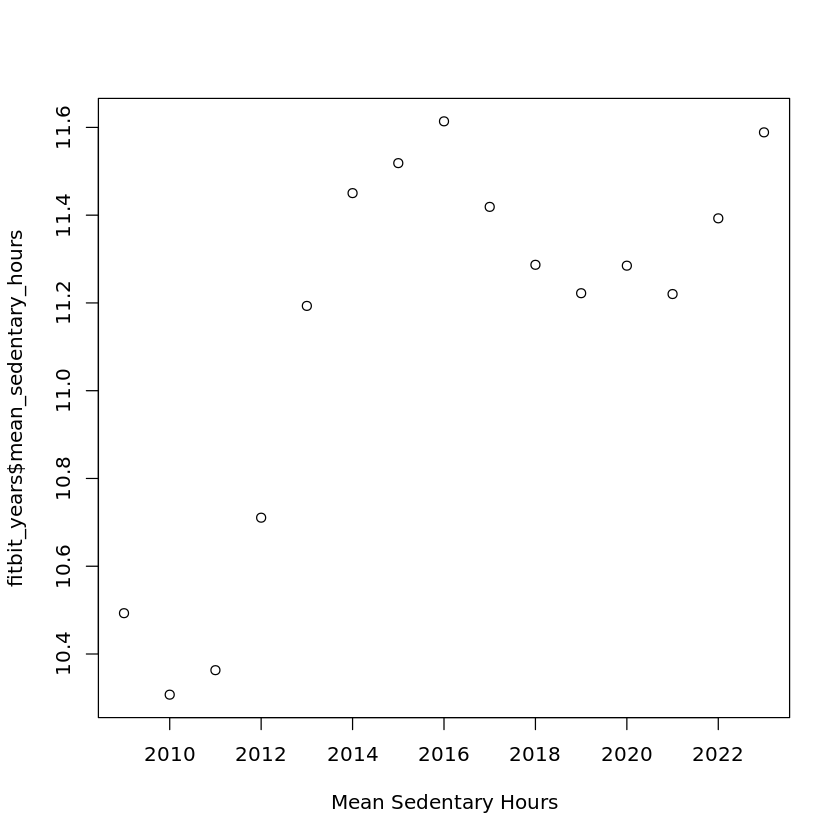

In [16]:
plot( fitbit_years$year, fitbit_years$mean_steps,
     main = "", xlab = "Mean Steps")

plot( fitbit_years$year, fitbit_years$mean_sleep_hours,
     main = "", xlab = "Mean Sleep Hours")

plot(fitbit_years$year, fitbit_years$mean_sedentary_hours,
     main = "", xlab = "Mean Sedentary Hours")



In [17]:
### Reading in covariates and outcomes

# Grabbing files from bucket
files <- paste0("datasets/",c("demographics",
                              "obesity_bmi",
                              "diabetes",
                              "hypertension",
                              "afib",
                              "heart_failure", 
#                               "hyperlipidemia",
#                               "cad",
#                               "mi","stroke","ckd","masld","copd",
                              "major_depressive_disorder",
                              "sleep_apnea",
                              "smoking","alcohol_drinks","education"),".csv")
files <- c(files,c("datasets/closest_bmi.csv","datasets/closest_bp.csv"))
dat_list <- lapply(files,read_bucket)


# Grabbing local files
files_local <- c(paste0("./",c("cad", "hyperlipidemia", "long_covid", "pad", "phtn" ,
                               "stroke","ckd","masld","copd"),".csv"))
dat_local_list <- lapply(files_local, read.csv)

In [18]:
# Merging files
merged <- Reduce(function(x,y) {
    if ("anchor_date" %in% colnames(x)) x[, anchor_date := NULL]
    if ("anchor_date" %in% colnames(y)) y[, anchor_date := NULL]
    merge(x,y,all.x=TRUE,all.y=TRUE)
    },dat_list)

merged_local <- Reduce(function(x,y) {
    if ("anchor_date" %in% colnames(x)) x[, anchor_date := NULL]
    if ("anchor_date" %in% colnames(y)) y[, anchor_date := NULL]
    merge(x,y,all.x=TRUE,all.y=TRUE)
    },dat_local_list)


merged <- merge(merged,merged_local,by="person_id", all.x=TRUE)
merged_tb1 <- merge(fitbit_agg,merged,by="person_id", all.x=TRUE)

In [19]:
#Recode variables
merged_tb1[,race_recode := recode_race_wbo(race)] 
merged_tb1[,sex_recode := recode_sex_fm(sex)]
merged_tb1[,education_recode := recode_edu(education_status)]
merged_tb1[,smoking_recode := recode_smoking(smoking_status)]

merged_tb1[,bmi := closest_bmi_value]
merged_tb1[,alcohol_drinks_recode := recode_alcohol_drinks(alcohol_drinks_status)]
merged_tb1[,cad_status := ifelse(is.na(cad_entry_date),FALSE,cad_status)]
# merged_tb1[,cancer_status := ifelse(is.na(cancer_entry_date),FALSE,cancer_status)]
merged_tb1[,alcohol_drinks_audit_score := alcohol_drinks_audit_score(alcohol_drinks_status)]
merged_tb1[,obesity_bmi_status := !is.na(obesity_bmi_entry_date)]

# Getting baseline dates
merged_tb1[,baseline_obesity_bmi := get_baseline_status(obesity_bmi_entry_date,min_fitbit_date)]
merged_tb1[,baseline_diabetes := get_baseline_status(diabetes_entry_date,min_fitbit_date)]
merged_tb1[,baseline_hypertension := get_baseline_status(hypertension_entry_date,min_fitbit_date)]
merged_tb1[,baseline_afib := get_baseline_status(afib_entry_date,min_fitbit_date)]
merged_tb1[,baseline_heart_failure := get_baseline_status(heart_failure_entry_date,min_fitbit_date)]
merged_tb1[,baseline_hyperlipidemia := get_baseline_status(hyperlipidemia_entry_date,min_fitbit_date)]
merged_tb1[,baseline_cad := get_baseline_status(cad_entry_date,min_fitbit_date)]
# merged_tb1[,baseline_mi := get_baseline_status(mi_entry_date,min_fitbit_date)]
merged_tb1[,baseline_stroke := get_baseline_status(stroke_entry_date,min_fitbit_date)]
merged_tb1[,baseline_ckd := get_baseline_status(ckd_entry_date,min_fitbit_date)]
merged_tb1[,baseline_masld := get_baseline_status(masld_entry_date,min_fitbit_date)]
merged_tb1[,baseline_copd := get_baseline_status(copd_entry_date,min_fitbit_date)]
merged_tb1[,baseline_major_depressive_disorder := get_baseline_status(major_depressive_disorder_entry_date,min_fitbit_date)]
merged_tb1[,baseline_sleep_apnea := get_baseline_status(sleep_apnea_entry_date,min_fitbit_date)]
merged_tb1[,baseline_long_covid := get_baseline_status(long_covid_entry_date,min_fitbit_date)]


# Getting incident dates
merged_tb1[,incident_obesity_bmi := get_incident_status(obesity_bmi_entry_date,min_fitbit_date)]
merged_tb1[,incident_diabetes := get_incident_status(diabetes_entry_date,min_fitbit_date)]
merged_tb1[,incident_hypertension := get_incident_status(hypertension_entry_date,min_fitbit_date)]
merged_tb1[,incident_afib := get_incident_status(afib_entry_date,min_fitbit_date)]
merged_tb1[,incident_heart_failure := get_incident_status(heart_failure_entry_date,min_fitbit_date)]
merged_tb1[,incident_hyperlipidemia := get_incident_status(hyperlipidemia_entry_date,min_fitbit_date)]
merged_tb1[,incident_cad := get_incident_status(cad_entry_date,min_fitbit_date)]
# merged_tb1[,incident_mi := get_incident_status(mi_entry_date,min_fitbit_date)]
merged_tb1[,incident_stroke := get_incident_status(stroke_entry_date,min_fitbit_date)]
merged_tb1[,incident_ckd := get_incident_status(ckd_entry_date,min_fitbit_date)]
merged_tb1[,incident_masld := get_incident_status(masld_entry_date,min_fitbit_date)]
merged_tb1[,incident_copd := get_incident_status(copd_entry_date,min_fitbit_date)]
merged_tb1[,incident_major_depressive_disorder := get_incident_status(major_depressive_disorder_entry_date,min_fitbit_date)]
merged_tb1[,incident_sleep_apnea := get_incident_status(sleep_apnea_entry_date,min_fitbit_date)]
merged_tb1[,incident_long_covid := get_incident_status(long_covid_entry_date,min_fitbit_date)]


merged_tb1[,age_at_baseline := as.numeric(as.Date(min_fitbit_date) - as.Date(date_of_birth)) / 365.25]

cat("\nOutlier BMI's (bmi > 100 or < 15) set to NA")
merged_tb1[bmi > 100 | bmi < 15,bmi := NA]

Found the following levels for race
         American Indian or Alaska Native 
                                      157 
                                    Asian 
                                     1214 
                Black or African American 
                                     1848 
                   I prefer not to answer 
                                       35 
          Middle Eastern or North African 
                                      177 
                 More than one population 
                                     1762 
Native Hawaiian or Other Pacific Islander 
                                        7 
                           None Indicated 
                                     1689 
                            None of these 
                                      277 
                                PMI: Skip 
                                      251 
                                    White 
                                    20317 

Mapping:
I prefer

In [20]:
# Table 1
tb1 <- summaryM(age_at_baseline + sex_recode + race_recode + education_recode + alcohol_drinks_audit_score + 
                smoking_recode + bmi + closest_bp_systolic  +
                mean_steps + mean_sedentary_hours + mean_lightly_active_minutes + mean_fairly_active_minutes +
                mean_very_active_minutes +
                incident_obesity_bmi + 
                incident_hypertension + 
                incident_diabetes + 
                incident_afib + 
                incident_heart_failure + 
#                 incident_hyperlipidemia + 
                incident_cad + 
#                 incident_mi + 
                incident_stroke + 
                incident_ckd + 
                incident_masld +
                incident_copd + 
                incident_major_depressive_disorder +
                incident_sleep_apnea +
                incident_long_covid ~
                1, data = merged_tb1)
display_hmisc_summary(tb1)

. 
 
 N 
 N=27734 
 
 
 
 
 age_at_baseline 
 27734 
 39.0 54.1 66.6 52.6 ± 16.4 
 
 
 sex_recode 
 27627 
 
 
 
     Female 
 
 0.69 19066 ⁄ 27627 
 
 
     Male 
 
 0.31 8561 ⁄ 27627 
 
 
 race_recode 
 25759 
 
 
 
     Black 
 
 0.07 1848 ⁄ 25759 
 
 
     Other 
 
 0.14 3594 ⁄ 25759 
 
 
     White 
 
 0.79 20317 ⁄ 25759 
 
 
 education_recode 
 27542 
 
 
 
     college 
 
 0.65 17813 ⁄ 27542 
 
 
     no_college 
 
 0.09 2394 ⁄ 27542 
 
 
     some_college 
 
 0.27 7335 ⁄ 27542 
 
 
 alcohol_drinks_audit_score 
 26595 
 
 
 
     0 
 
 0.15 4058 ⁄ 26595 
 
 
     1 
 
 0.33 8734 ⁄ 26595 
 
 
     2 
 
 0.23 6002 ⁄ 26595 
 
 
     3 
 
 0.15 4063 ⁄ 26595 
 
 
     4 
 
 0.14 3738 ⁄ 26595 
 
 
 smoking_recode 
 27209 
 
 
 
     No 
 
 0.63 17232 ⁄ 27209 
 
 
     Yes 
 
 0.37 9977 ⁄ 27209 
 
 
 bmi 
 23383 
 24.60 28.50 33.90 29.96 ±  7.53 
 
 
 closest_bp_systolic 
 13775 
 113.0 123.0 134.0 124.4 ±  16.1 
 
 
 mean_steps 
 27734 
 4913 6926 9284 7306 ± 3414 
 
 
 mean_sedentary_hours 
 27734 
 10.69 11.71 12.70 11.66 ±  1.61 
 
 
 mean_lightly_active_minutes 
 27734 
 174.8 216.6 262.0 219.9 ±  66.6 
 
 
 mean_fairly_active_minutes 
 27734 
 7.17 13.43 22.93 17.52 ± 16.04 
 
 
 mean_very_active_minutes 
 27734 
 4.68 12.00 24.76 17.96 ± 19.47 
 
 
 incident_obesity_bmi 
 14963 
 
 
 
     FALSE 
 
 0.84 12499 ⁄ 14963 
 
 
     TRUE 
 
 0.16 2464 ⁄ 14963 
 
 
 incident_hypertension 
 10783 
 
 
 
     FALSE 
 
 0.72 7784 ⁄ 10783 
 
 
     TRUE 
 
 0.28 2999 ⁄ 10783 
 
 
 incident_diabetes 
 25302 
 
 
 
     FALSE 
 
 0.99 24923 ⁄ 25302 
 
 
     TRUE 
 
 0.01 379 ⁄ 25302 
 
 
 incident_afib 
 26622 
 
 
 
     FALSE 
 
 0.99 26284 ⁄ 26622 
 
 
     TRUE 
 
 0.01 338 ⁄ 26622 
 
 
 incident_heart_failure 
 27233 
 
 
 
     FALSE 
 
 0.99 27028 ⁄ 27233 
 
 
     TRUE 
 
 0.01 205 ⁄ 27233 
 
 
 incident_cad 
 25632 
 
 
 
     FALSE 
 
 0.98 25059 ⁄ 25632 
 
 
     TRUE 
 
 0.02 573 ⁄ 25632 
 
 
 incident_stroke 
 27379 
 
 
 
     FALSE 
 
 1 27249 ⁄ 27379 
 
 
     TRUE 
 
 0 130 ⁄ 27379 
 
 
 incident_ckd 
 26532 
 
 
 
     FALSE 
 
 0.99 26158 ⁄ 26532 
 
 
     TRUE 
 
 0.01 374 ⁄ 26532 
 
 
 incident_masld 
 25985 
 
 
 
     FALSE 
 
 0.97 25276 ⁄ 25985 
 
 
     TRUE 
 
 0.03 709 ⁄ 25985 
 
 
 incident_copd 
 26280 
 
 
 
     FALSE 
 
 1 26189 ⁄ 26280 
 
 
     TRUE 
 
 0 91 ⁄ 26280 
 
 
 incident_major_depressive_disorder 
 21485 
 
 
 
     FALSE 
 
 0.95 20381 ⁄ 21485 
 
 
     TRUE 
 
 0.05 1104 ⁄ 21485 
 
 
 incident_sleep_apnea 
 22919 
 
 
 
     FALSE 
 
 0.94 21639 ⁄ 22919 
 
 
     TRUE 
 
 0.06 1280 ⁄ 22919 
 
 
 incident_long_covid 
 27629 
 
 
 
     FALSE 
 
 1 27535 ⁄ 27629 
 
 
     TRUE 
 
 0 94 ⁄ 27629 
 
 
 
 a b c represent the lower quartile a , the median b , and the upper quartile c for continuous variables.  x ± s represents X  ± 1 SD.   N is the number of non-missing values.

In [21]:
library(corrplot)

corrplot 0.95 loaded



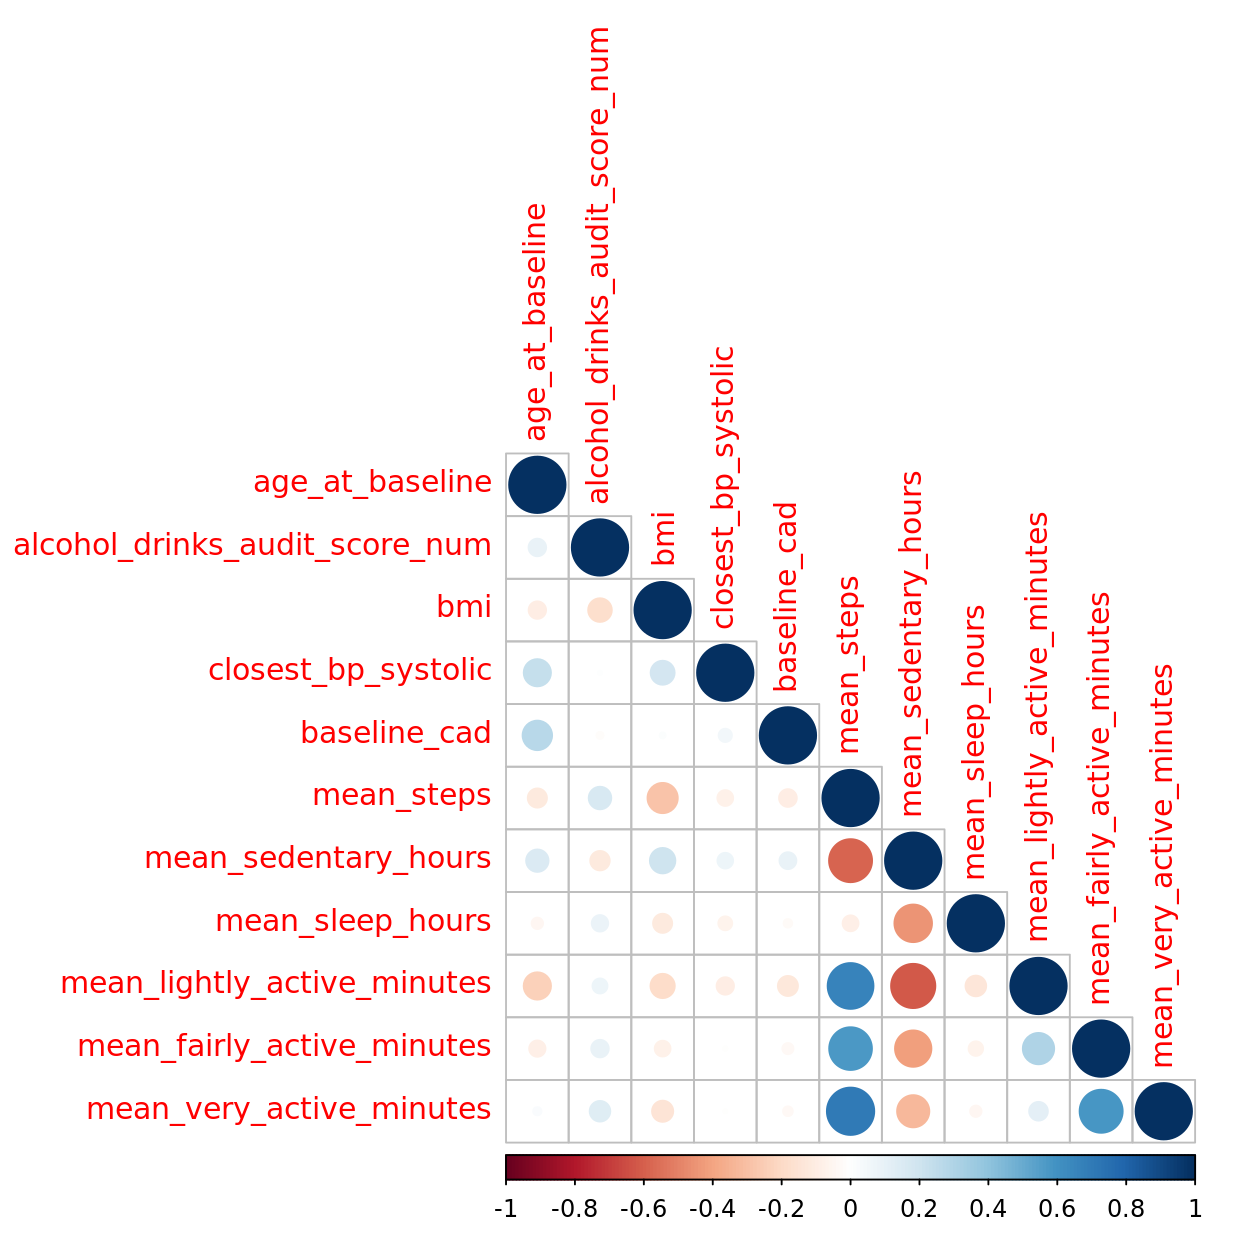

In [22]:
options(repr.plot.res = 180)
merged_tb1[,alcohol_drinks_audit_score_num :=  as.numeric(alcohol_drinks_audit_score)]
M <- cor(na.omit(merged_tb1[, c("age_at_baseline","alcohol_drinks_audit_score_num", 
                                   "bmi", "closest_bp_systolic", "baseline_cad",
                "mean_steps", "mean_sedentary_hours", "mean_sleep_hours",
                "mean_lightly_active_minutes", "mean_fairly_active_minutes",
                "mean_very_active_minutes")]))
corrplot(M, diag = T, type = "lower")

In [23]:
# Cutting into months
fitbit_dat <- fitbit_dat[order(date)]
fitbit_dat[, day := as.numeric(date - min(date)), .(person_id)]
fitbit_dat[, month := cut(day, seq(0,30*10000,30), right = F, include.lowest = T, label = F)]
fitbit_dat[, n_obs := length(unique(date)), .(person_id, month)]

cat("\nInitial cohort N:", length(unique(fitbit_dat$person_id)))
cat("\nDays:", nrow(fitbit_dat))

fitbit_dat_month <- fitbit_dat[, .(mean_steps = mean(steps, na.rm = T),
                                   mean_fairly_active_minutes = mean(fairly_active_minutes, na.rm =T),
                                   mean_sedentary_hours = mean(sedentary_minutes, na.rm = T)/60,
                                   mean_lightly_active_minutes = mean(lightly_active_minutes, na.rm = T),
#                                    mean_steps_sedentary_ratio = mean(steps_sedentary_ratio, na.rm = T),
                                   mean_wear_time = mean(wear_time, na.rm=T),
                                   n_obs = n_obs[1],
                                   date = date[1]),
                              .(person_id, month)]


cat("\n\nAnalysis switching to months")
cat("\nN:", length(unique(fitbit_dat_month$person_id)))
init_n <- nrow(fitbit_dat_month)
cat("\nMonths:", init_n)

fitbit_dat_month <- fitbit_dat_month[n_obs >= 15]
final_n <- nrow(fitbit_dat_month)
cat("\n\nRemoving months < 15 observations")
cat("\nN:", length(unique(fitbit_dat_month$person_id)))
cat("\nMonths:", nrow(fitbit_dat_month))
cat("\nPercentage removed:", round(100 * ((init_n - final_n) / init_n),1))


Initial cohort N: 26078
Days: 13682755

Analysis switching to months
N: 26078
Months: 626522

Removing months < 15 observations
N: 23320
Months: 490356
Percentage removed: 21.7

In [24]:
# Attach necessary variables
fitbit_dat_month <- merge(fitbit_dat_month, last_enc, by = "person_id")
fitbit_dat_month <- merge(fitbit_dat_month, merged_tb1[, c("person_id",
                                                           "obesity_bmi_entry_date",
                                                           "diabetes_entry_date", 
                                                           "hypertension_entry_date",
                                                           "afib_entry_date", 
                                                           "heart_failure_entry_date",
                                                           "cad_entry_date",
#                                                            "mi_entry_date",
                                                           "stroke_entry_date",
                                                           "ckd_entry_date",
                                                           "masld_entry_date",
                                                           "copd_entry_date",
                                                           "major_depressive_disorder_entry_date",
                                                           "sleep_apnea_entry_date",
                                                           "long_covid_entry_date"
                                                          )], allow.cartesian=TRUE)

In [25]:
# Fixing data type 
fitbit_dat_month$obesity_bmi_entry_date <- as.IDate(fitbit_dat_month$obesity_bmi_entry_date)
fitbit_dat_month$diabetes_entry_date <- as.IDate(fitbit_dat_month$diabetes_entry_date)
fitbit_dat_month$hypertension_entry_date <- as.IDate(fitbit_dat_month$hypertension_entry_date)
fitbit_dat_month$afib_entry_date <- as.IDate(fitbit_dat_month$afib_entry_date)
fitbit_dat_month$heart_failure_entry_date <- as.IDate(fitbit_dat_month$heart_failure_entry_date)
fitbit_dat_month$cad_entry_date <- as.IDate(fitbit_dat_month$cad_entry_date)
# fitbit_dat_month$mi_entry_date <- as.IDate(fitbit_dat_month$mi_entry_date)
fitbit_dat_month$stroke_entry_date <- as.IDate(fitbit_dat_month$stroke_entry_date)
fitbit_dat_month$ckd_entry_date <- as.IDate(fitbit_dat_month$ckd_entry_date)
fitbit_dat_month$masld_entry_date <- as.IDate(fitbit_dat_month$masld_entry_date)
fitbit_dat_month$copd_entry_date <- as.IDate(fitbit_dat_month$copd_entry_date)
fitbit_dat_month$major_depressive_disorder_entry_date <- as.IDate(fitbit_dat_month$major_depressive_disorder_entry_date)
fitbit_dat_month$sleep_apnea_entry_date <- as.IDate(fitbit_dat_month$sleep_apnea_entry_date)
fitbit_dat_month$long_covid_entry_date <- as.IDate(fitbit_dat_month$long_covid_entry_date)


In [31]:
act_var1 <- "steps"
act_var2 <- "sedentary_hours"
model <- "model_2"

dx_list <- list(
    obesity = list(
        title="Obesity",
        dataset_name="obesity_bmi"
    ),
    dm = list(
        title="Diabetes",
        dataset_name="diabetes"
    ),
    htn = list(
        title="Hypertension",
        dataset_name="hypertension"
    ),
    afib = list(
        title="Atrial Fibrillation",
        dataset_name="afib"
    ),
    hf = list(
        title="Heart Failure",
        dataset_name="heart_failure"
    ),
    cad = list(
        title="Coronary Artery Disease",
        dataset_name="cad"
    ),
    stroke = list(
        title="Stroke",
        dataset_name="stroke"
    )
    ckd = list(
        title="Chronic Kidney Disease",
        dataset_name="ckd"
    ),
    masld = list(
        title="MASLD",
        dataset_name="masld"
    ),
    copd = list(
        title="COPD",
        dataset_name="copd"
    ),
    mdd = list(
        title="MDD",
        dataset_name="major_depressive_disorder"
    ),
    sla = list(
        title="Sleep Apnea",
        dataset_name="sleep_apnea"
    )
    
)


In [32]:

plot_results_heatmap <- function(out, dat_imp, act_var1, act_var2) 
{
    # Extract complete dataset
    d1 <- as.data.table(complete(dat_imp, 0))

    # Define grid for partial dependence
    act_var1_seq <- seq(0, 20000, by = 1000)  # Adjusted sequence for act_var1
    act_var2_seq <- seq(4, 18, by = 0.5)      # Adjusted sequence for act_var2

    # Create grid
    grid <- expand.grid(act_var1 = act_var1_seq, act_var2 = act_var2_seq)

    # Convert to data.table
    grid_data <- as.data.table(grid)


    # Compute predictions over the grid
    grid_data[, estimate := sapply(1:nrow(grid_data), function(i) {
        Predict(out, mean_steps = grid_data$act_var1[i], 
                mean_sedentary_hours = grid_data$act_var2[i],
                fun = exp,
                ref.zero=TRUE)$yhat
    })]

    
    # Generate heatmap plot
    p_heatmap <- ggplot(grid_data, aes(y = act_var1, x = act_var2, z = estimate)) +
        geom_contour_filled(breaks = c(0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, Inf), show.legend = TRUE) +  
        scale_fill_viridis_d(option = "viridis") +
        labs(y = "Steps", x = "Sedentary Hours", fill = "Hazard Ratio") +
        scale_y_continuous(breaks = seq(0, 20000, 2000), expand = c(0, 0)) +
        scale_x_continuous(breaks = seq(4, 18, 2), expand = c(0, 0)) +
        theme_bw() +
        theme(
            text = element_text(size = 18, family = "Helvetica"),
            panel.grid = element_blank(),            
            panel.border = element_blank(),
            axis.text.x = element_text(angle = 0, size = 12),  # Rotate x-axis labels
            axis.text.y = element_text(size = 12),  # Adjust y-axis labels
            axis.ticks = element_line(size = 0.5)  # Add ticks 
        )
#         # Add points where the prediction is closest to 1
#         geom_point(data = min_diff_points, aes(x = act_var1, y = act_var2), 
#                    color = "white", size = 3, shape = 16) 


    # Save and display
    ggsave("heatmap_plot.png", p_heatmap, width = 10, height = 6)
    IRdisplay::display_png(file = "heatmap_plot.png", width = 900)
    
    
    
   
}



plot_results_lineplot <- function(out, dat_imp, act_var1, act_var2) {
   
    # Extract complete dataset
    d1 <- as.data.table(complete(dat_imp, 0))
    

    # Define grid for partial dependence
    act_var1_seq <- seq(0, 20000, by = 1000) 
    act_var2_seq <- c(8,10,12,14) 


    # Create grid
    grid <- expand.grid(act_var1 = act_var1_seq, act_var2 = act_var2_seq)

    # Convert to data.table
    grid_data <- as.data.table(grid)


    # Compute predictions over the grid 
    # HR = Hazard (grid_data$act_var1[i], grid_data$act_var2[i]) / Hazard (median(act_var1), median(act_var2))
    h_prd <- as.data.table(t(sapply(1:nrow(grid_data), 
                          function(i) {
                            Predict(out, 
                                    mean_steps = grid_data$act_var1[i], 
                                    mean_sedentary_hours = grid_data$act_var2[i],
                                    fun = exp,
                                    ref.zero=TRUE)
                          }
                         )))

    
    
    # Making sure all columns are numeric for plotting
    h_prd[, `:=`(
      mean_steps = as.numeric(mean_steps),
      mean_sedentary_hours = as.numeric(mean_sedentary_hours),
      yhat = as.numeric(yhat),
      lower = as.numeric(lower),
      upper = as.numeric(upper)

    )]
    
        
    # Printing table
    options(datatable.print.nrows = 1e5)  # 100,000 rows
    print(h_prd[, .(mean_steps, mean_sedentary_hours, yhat, lower, upper)])

    
    # Plotting
    p <- ggplot(h_prd, aes(x = mean_steps, y = yhat, color = factor(mean_sedentary_hours,
                                                                   labels = c('8 hours', '10 hours', '12 hours', '14 hours')))) +
        geom_line(size = 1) +
#         geom_smooth(aes(ymin = lower, ymax = upper, fill = factor(mean_sedentary_hours)),
#                     alpha = 0.2, color = NA,
#                    stat = "identity") +
        geom_hline(yintercept = 1, linetype = "dashed") +
        labs(
          y = "Hazard Ratio",
          x = "Steps",
          color = "Sedentary Percentile",
          fill = "Sedentary Percentile"
        ) +
        scale_x_continuous(breaks = scales::pretty_breaks(9), limits = c(0, 20000)) + 
        scale_y_continuous(breaks = scales::pretty_breaks(9), limits = c(0, 4)) + 
        theme_bw(base_size = 16) +
        scale_fill_viridis_d(option = "D") +
        scale_color_viridis_d(option = "D") +
        theme(
          legend.position = c(0.8, .85),
          panel.grid = element_blank(),
          axis.line = element_line(colour = "black"),
          panel.border = element_blank(),
          panel.background = element_blank()
        )


        ggsave("temp_plot1.png", p, width = 8, height = 6)
        IRdisplay::display_png(file = "temp_plot1.png", width = 800)
    
    

}


plot_cuminc_lineplot <- function(out, dat_imp, act_var1, act_var2, timepoint = 3) {
    
    # Extract complete dataset
    d1 <- as.data.table(complete(dat_imp, 0))
    
    
    # Prediction grid
    act_var1_seq <- seq(0, 20000, by = 1000)
    act_var2_seq <- c(8, 10, 12, 14)
    

    # Create grid
    grid <- expand.grid(act_var1 = act_var1_seq, act_var2 = act_var2_seq)
    
  
    grid <- as.data.table(grid)
    
 
    predictions <- rbindlist(lapply(timepoint, function(t) {
      pred <- Predict(out, mean_steps = act_var1_seq, mean_sedentary_hours = act_var2_seq, 
                      time = timepoint, 
                      fun = function(x) 1-x)
      data.table(time = paste0("Year ", timepoint), pred)
    })) 

    predictions <- as.data.table(predictions)
    predictions[, sedentary := factor(mean_sedentary_hours, levels = act_var2_seq, labels = paste0(act_var2_seq, " hrs"))]
    predictions[, time := paste0("Year ", timepoint)]

    # Plot
    p <- ggplot(predictions, aes(x = mean_steps, y = yhat, color = sedentary, fill = sedentary)) +
      geom_line(size = 1.2) +
    #   geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.2, color = NA) +
        labs(
          y = "Cumulative Incidence",
          x = "Steps",
          color = "Sedentary Percentile",
          fill = "Sedentary Percentile"
        ) +
        scale_x_continuous(breaks = scales::pretty_breaks(9), limits = c(0, 20000)) + 
        scale_y_continuous(breaks = scales::pretty_breaks(9)) + 
        theme_bw(base_size = 16) +
        scale_fill_viridis_d(option = "D") +
        scale_color_viridis_d(option = "D") +
        theme(
          legend.position = c(0.8, .85),
          panel.grid = element_blank(),
          axis.line = element_line(colour = "black"),
          panel.border = element_blank(),
          panel.background = element_blank()
        )
        
    ggsave("cuminc_plot.png", p, width = 8, height = 6)
    IRdisplay::display_png(file = "cuminc_plot.png", width = 800)
    
}
                                                      

# Stroke

Frequencies of Missing Values Due to Each Variable
Surv(time1, time2, status)                 mean_steps 
                     53332                          0 
      mean_sedentary_hours             mean_wear_time 
                         0                          0 
           age_at_baseline                 sex_recode 
                         0                          0 
            smoking_recode alcohol_drinks_audit_score 
                         0                          0 
          education_recode 
                         0 

Cox Proportional Hazards Model

Hmisc::fit.mult.impute(formula = f, fitter = cph, xtrans = dat_imp, 
    data = d1, pr = FALSE, fitargs = list(surv = T, y = T, x = T))


                       Model Tests        Discrimination    
                                                 Indexes    
Obs    433868    LR chi2     69.06        R2       0.041    
Events     95    d.f.           15    R2(15,433868)0.000    
Center 2.3386    Pr(> chi2) 0.0000    

Factor,Low,High,Diff.,Effect,S.E.,Lower 0.95,Upper 0.95,Type,p
mean_steps,5416.8,10258.59,4841.79,-0.67,0.21,-1.08,-0.25,1,1.605e-03
Hazard Ratio,5416.8,10258.59,4841.79,0.51,,0.34,0.78,2,NA
mean_sedentary_hours,10.41,12.52,2.11,-0.03,0.16,-0.33,0.28,1,8.653e-01
Hazard Ratio,10.41,12.52,2.11,0.97,,0.72,1.32,2,NA
mean_wear_time,16.96,18.88,1.93,0.22,0.14,-0.06,0.5,1,1.165e-01
Hazard Ratio,16.96,18.88,1.93,1.25,,0.95,1.64,2,NA
age_at_baseline,40.13,63.34,23.22,0.9,0.18,0.55,1.25,1,4.532e-07
Hazard Ratio,40.13,63.34,23.22,2.46,,1.74,3.5,2,NA
sex_recode - Male:Female,1,2,,-0.07,0.24,-0.54,0.39,1,7.584e-01
Hazard Ratio,1,2,,0.93,,0.58,1.48,2,NA


,Chi-Square,d.f.,P
mean_steps,9.9584,2,0.0069
Nonlinear,0.1203,1,0.7287
mean_sedentary_hours,1.8538,2,0.3958
Nonlinear,1.8416,1,0.1748
mean_wear_time,2.4635,1,0.1165
age_at_baseline,29.6219,2,<0.0001
Nonlinear,3.0357,1,0.0815
sex_recode,0.0946,1,0.7584
smoking_recode,1.6014,1,0.2057
alcohol_drinks_audit_score,13.162,4,0.0105


[1] "Test of PH"

                              chisq df      p
rcs(mean_steps, 3)           11.168  2 0.0038
rcs(mean_sedentary_hours, 3)  3.444  2 0.1787
mean_wear_time                0.625  1 0.4294
rcs(age_at_baseline, 3)       1.453  2 0.4837
sex_recode                    1.935  1 0.1642
smoking_recode                0.026  1 0.8719
alcohol_drinks_audit_score    1.695  4 0.7916
education_recode              0.904  2 0.6364
GLOBAL                       19.154 15 0.2068

Exclude data after censor date
N: 18275
Months 436459
Events: 400

Exclude events < 180 days after first monitoring date
N: 18036
Months 431410
Events: 118

Exclude events > 2 years after last monitoring date
N: 18018
Months 431185
Events: 100

Iteration 8 

Multiple Imputation using Bootstrap and PMM

Hmisc::aregImpute(formula = f, data = covariates, n.impute = 5, 
    pr = TRUE)

n: 19384 	p: 11 	Imputations: 5  	nk: 3 

Number of NAs:
            imp_mean_steps   imp_mean_sedentary_hours 
                         0                          0 
           age_at_baseline                 sex_recode 
                         0                         67 
               race_recode alcohol_drinks_audit_score 
                      1070                        712 
                       bmi            incident_stroke 
                      3793                         41 
          education_recode             smoking_recode 
                       131                        340 
       c

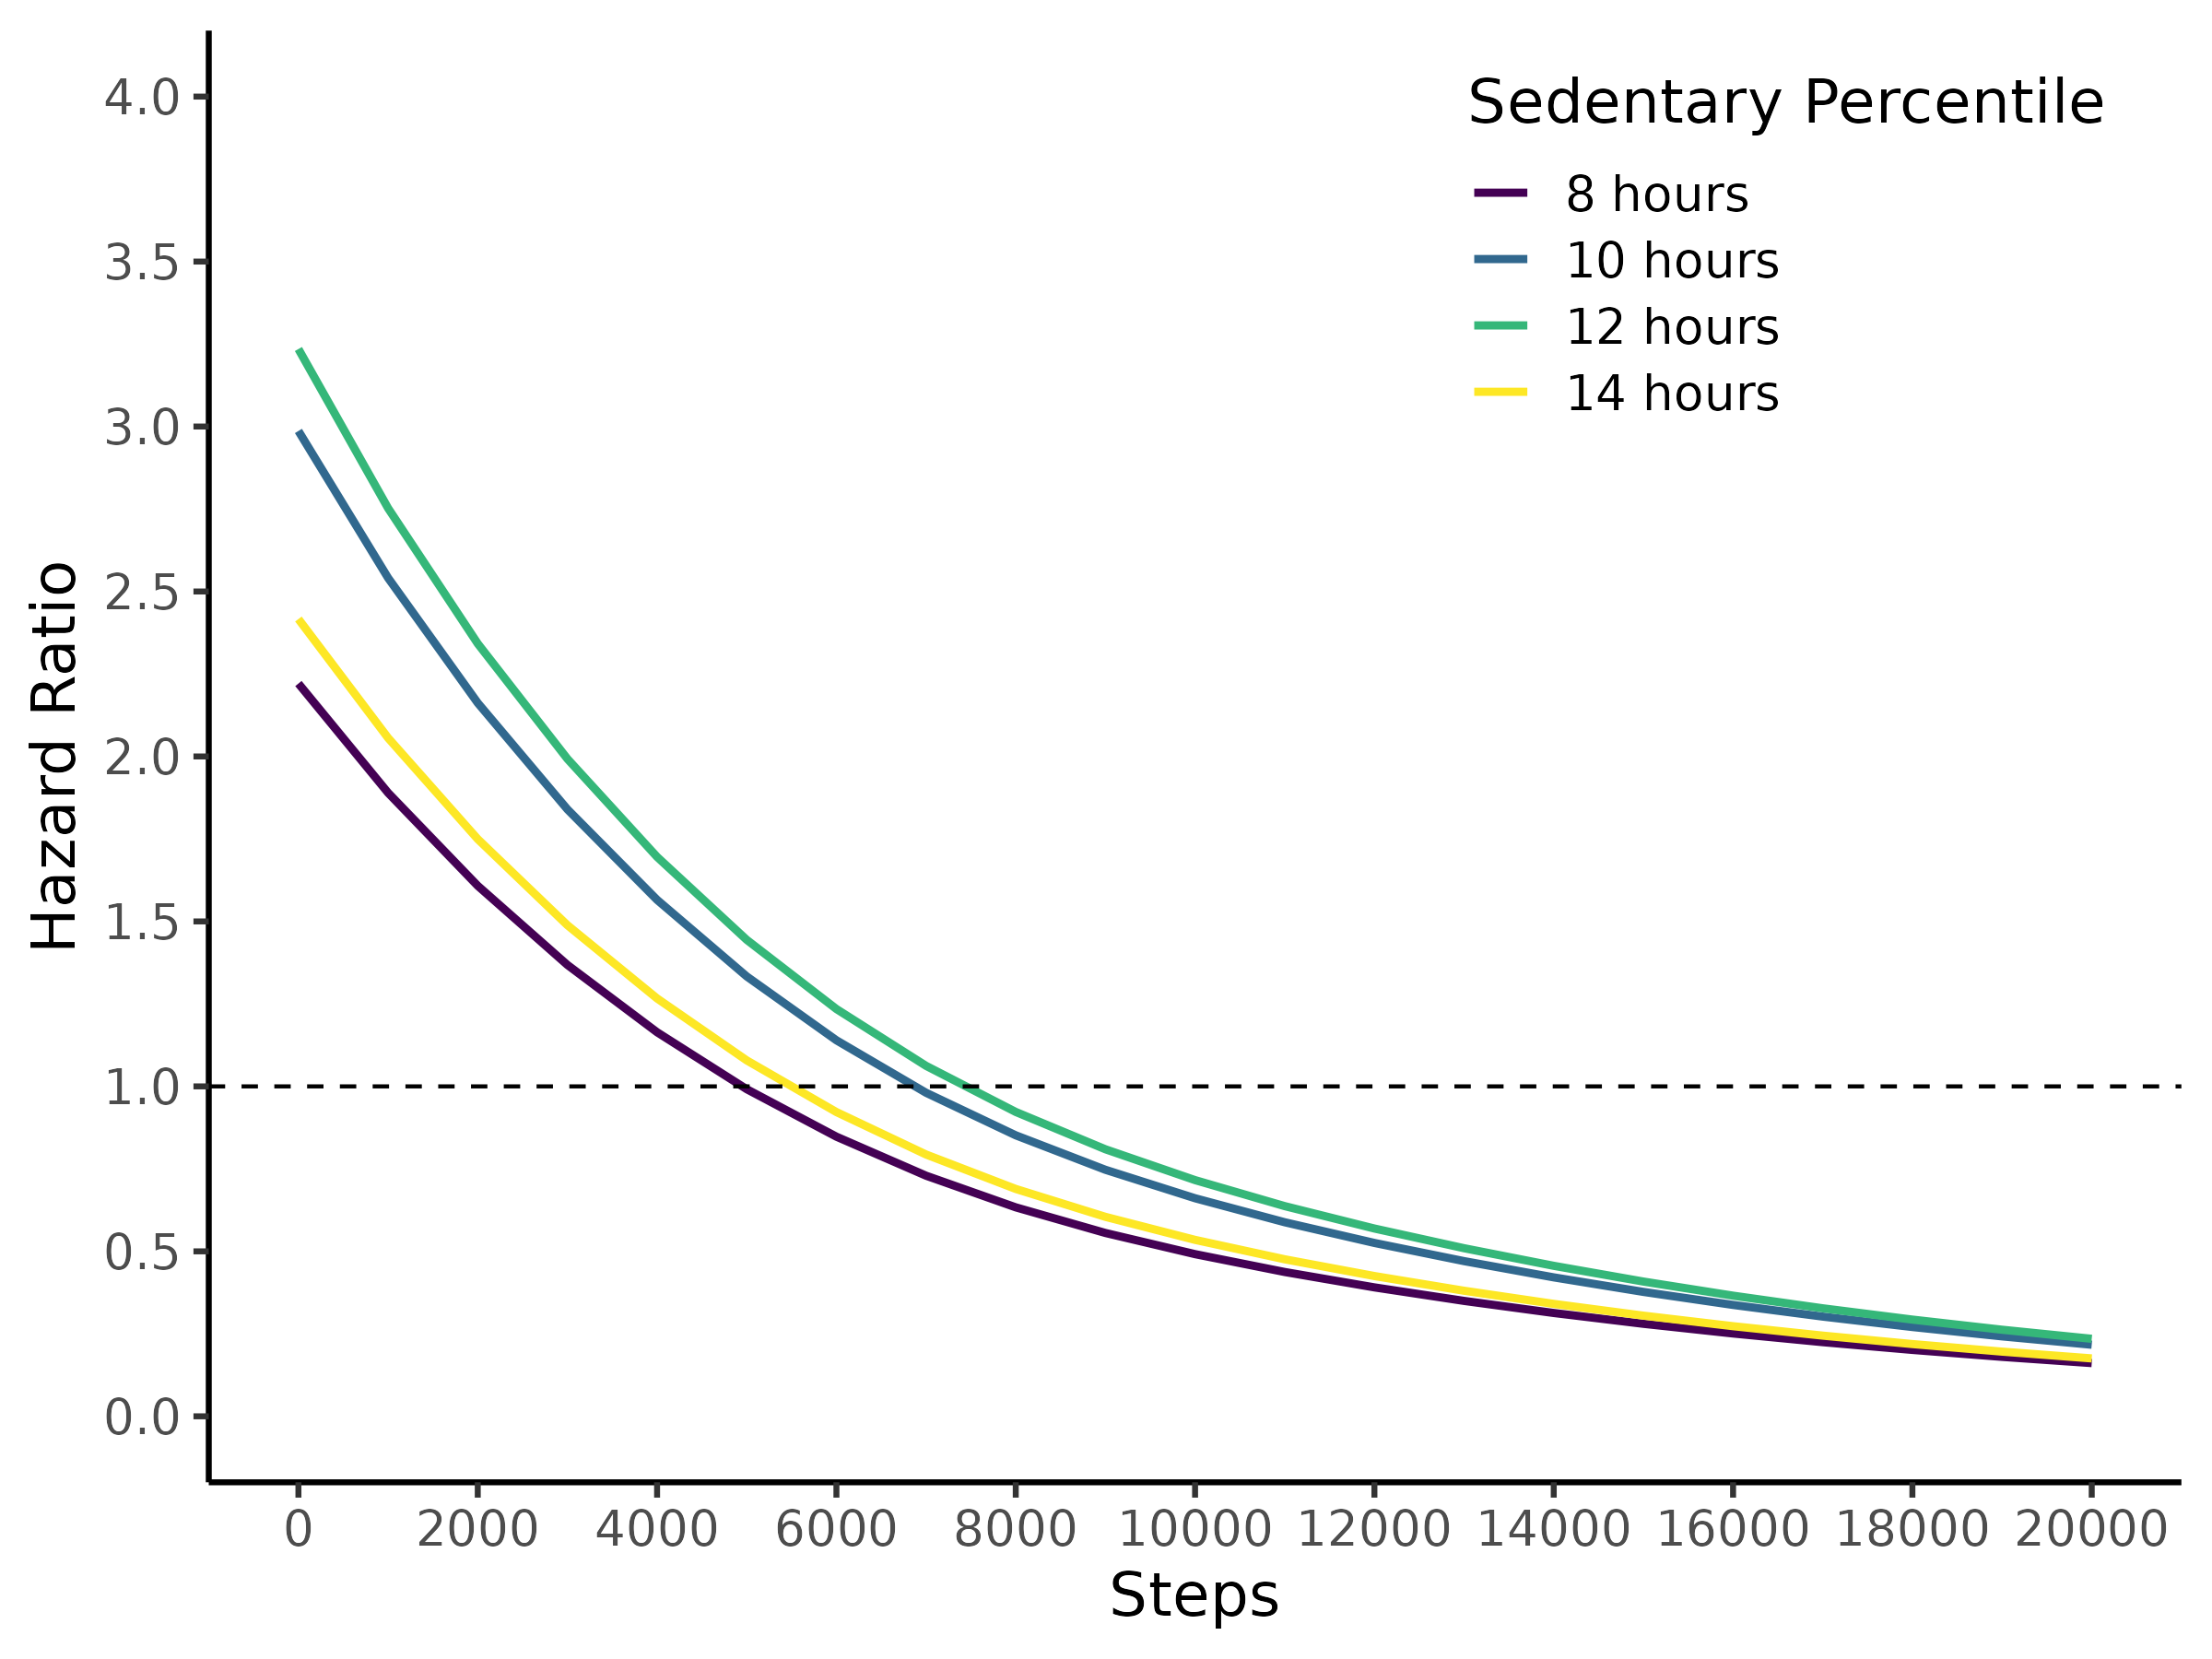

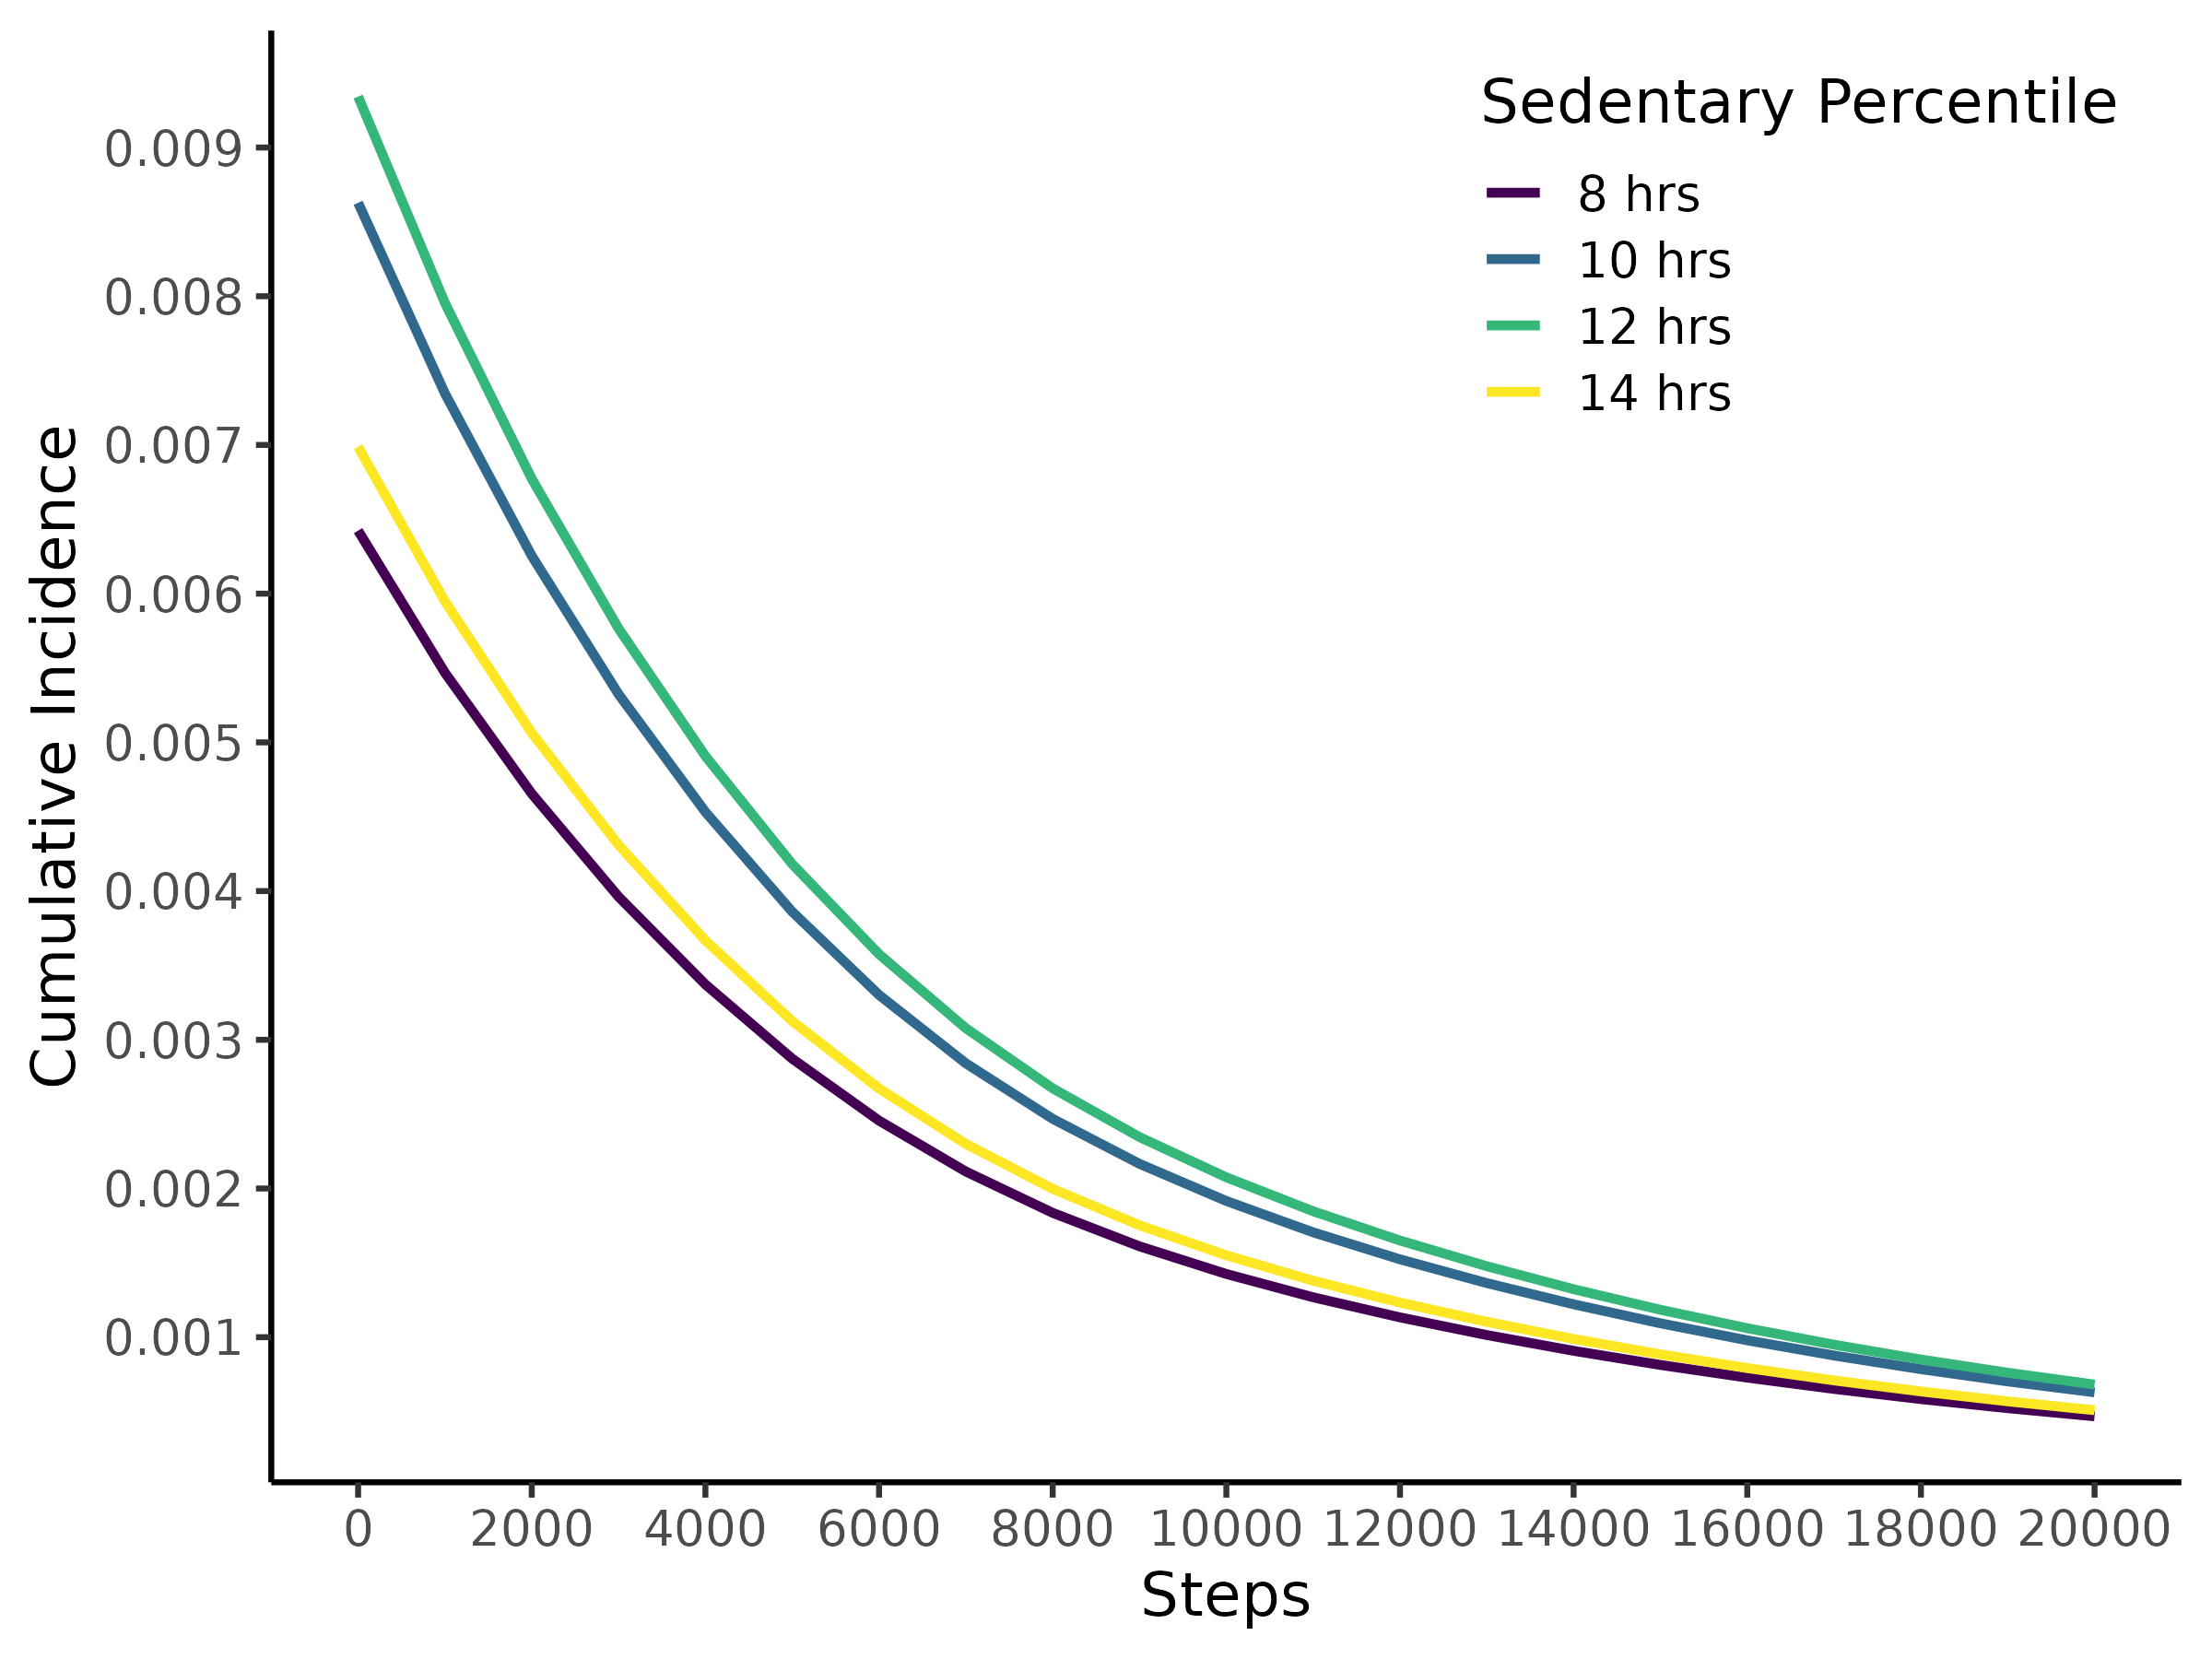

In [33]:
set_plot_dim(100,8,15)  

# for (dx in dx_list)
for (dx in dx_list)
{
    section_title <- dx$title
    IRdisplay::display_markdown(str_glue("# {section_title}"))
    dx_var <- dx$dataset_name
    dat_imp <- impute_dataset2(fitbit_dat_month, merged_tb1, dx_var, act_var1, act_var2)
    options(warn=-1) # rms is printing superfluous internal warnings about formatting
    m <- run_model2(model, dat_imp, act_var1, act_var2)
#     plot_results_heatmap(m, dat_imp, act_var1, act_var2)
    plot_results_lineplot(m, dat_imp, act_var1, act_var2)
    plot_cuminc_lineplot(m, dat_imp, act_var1, act_var2, timepoint = 3)
    options(warn=0)
}